# Multiple Linear Regression

Multiple Linear Regression is a supervised machine learning algorithm used to model the relationship between **one dependent variable** and **multiple independent variables**.

It extends Simple Linear Regression by allowing the model to use multiple input features to predict the target variable.

## Import Required Libraries

We import the required Python libraries for data manipulation, visualization, and machine learning.

In [1]:
from sklearn.datasets import fetch_california_housing

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

## Load the California Housing Dataset

The dataset used in this project is the **California Housing dataset**, which contains information about housing districts in California.

The goal is to **predict the median house price** using several features such as income, house age, number of rooms, population, etc.

In [2]:
california = fetch_california_housing()

## Dataset Information

The dataset is provided as a **dictionary-like object** containing:

- Data
- Target values
- Feature names
- Dataset description

In [4]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [7]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

## Dataset Description

The California Housing dataset contains the following features:

| Feature | Description |
|------|------|
| MedInc | Median income in the block group |
| HouseAge | Median house age in the block |
| AveRooms | Average number of rooms per household |
| AveBedrms | Average number of bedrooms per household |
| Population | Block population |
| AveOccup | Average number of household members |
| Latitude | Latitude of the block |
| Longitude | Longitude of the block |

Target Variable:

| Target | Description |
|------|------|
| Price | Median house value in the district |

In [8]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## Create DataFrame

We convert the dataset into a **Pandas DataFrame** so that it becomes easier to analyze and manipulate the data.

In [9]:
dataset = pd.DataFrame(california.data, columns=california.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Add Target Variable

The target variable (house price) is added to the dataset.

In [10]:
dataset['Price'] = california.target
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset Information

This step provides information about:

- Number of rows
- Number of columns
- Data types

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Check Missing Values

We check whether the dataset contains any missing values.

In [12]:
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

## Statistical Summary

The `describe()` function provides statistical information about the dataset including:

- Mean
- Standard deviation
- Minimum value
- Maximum value

In [13]:
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Correlation Analysis

Correlation measures how strongly two variables are related.

The correlation coefficient ranges between:

- **-1** → Perfect negative correlation  
- **0** → No correlation  
- **1** → Perfect positive correlation

In [14]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


## Correlation Heatmap

A heatmap is used to visualize the correlation between features.

<Axes: >

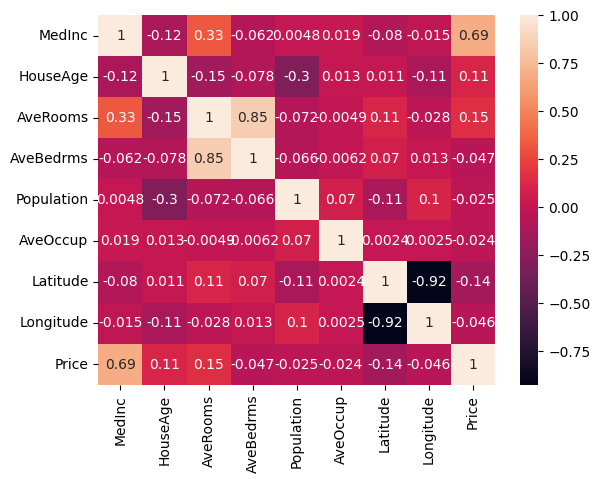

In [19]:
sns.heatmap(dataset.corr(),annot = True)

## Independent and Dependent Features

We divide the dataset into:

Independent Variables (X) → Input features

Dependent Variable (y) → Target variable

In [20]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

## Train-Test Split

The dataset is divided into two parts:

Training Data → Used to train the model  
Testing Data → Used to evaluate the model

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=10
)

## Feature Scaling

Feature scaling standardizes the features so that each feature contributes equally to the model.

Standardization Formula:

Z = (X − μ) / σ

Where

X = original value  
μ = mean  
σ = standard deviation

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train the Multiple Linear Regression Model

In [25]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Multiple Linear Regression Equation

The model follows the equation:

y = b₀ + b₁x₁ + b₂x₂ + b₃x₃ + ... + bₙxₙ

Where:

y → Predicted house price  
x₁, x₂, ... xₙ → Independent features  
b₀ → Intercept  
b₁, b₂ ... bₙ → Coefficients (slopes)

In [26]:
regression.coef_

array([ 0.82872299,  0.1231163 , -0.27068752,  0.32859106,  0.00213572,
       -0.02810091, -0.93017985, -0.89505497])

In [27]:
regression.intercept_

np.float64(2.0634768086491175)

### Predicting the X_test values to check the accuracy of model

In [29]:
y_pred = regression.predict(X_test)

## Performance Metrics

MAE = (1/n) Σ |yᵢ − ŷᵢ|

MSE = (1/n) Σ (yᵢ − ŷᵢ)²

R² measures how well the regression model explains the variance in the target variable.

R² = 1 − ( Σ(yᵢ − ŷᵢ)² / Σ(yᵢ − ȳ)² )


In [31]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
 
print("The Mean Square Error: ",mean_squared_error(y_test, y_pred))
print("The Mean Absolute Error : ",mean_absolute_error(y_test, y_pred))
print("The R2 Score : ",r2_score(y_test,y_pred))

The Mean Square Error:  0.5522332399363619
The Mean Absolute Error :  0.5371056943007961
The R2 Score :  0.593595852643664


## Linear Regression Assumptions

1. Linear relationship
2. Independence of errors
3. Homoscedasticity
4. Normal distribution of residuals


### 1. Linear Relationship

The first assumption is that there should be a **linear relationship between the independent variables and the dependent variable**.

This means that the change in the target variable should be proportional to the change in the input variables.

For example:

If income increases, house price may also increase in a roughly straight-line relationship.

If the relationship is highly non-linear, Linear Regression may not perform well.


### 2. Independence of Errors

The errors (residuals) should be **independent of each other**.

Residuals represent the difference between the actual values and the predicted values.

Residual formula:

Residual = Actual Value − Predicted Value

Each error should not depend on the previous error.  
This assumption is especially important for **time-series data**.


### 3. Homoscedasticity

Homoscedasticity means that the **variance of the residuals should remain constant across all predictions**.

In simple words:

The spread of errors should be roughly the same for all predicted values.

If the spread of residuals increases or decreases as predictions increase, this is called **heteroscedasticity**, which violates the assumption.


### 4. Normal Distribution of Residuals

The residuals should follow a **normal distribution**.

This means that the errors should be centered around zero and form a bell-shaped distribution.

This assumption helps ensure that statistical tests and confidence intervals for the model are valid.



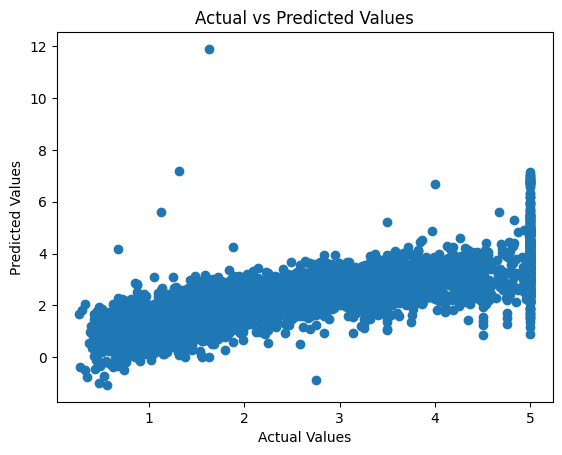

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

### Calculate Residuals

Residuals measure the difference between actual values and predicted values.

In [33]:
residuals = y_test - y_pred

### Distribution of Residuals

We check whether residuals follow a normal distribution.

If the curve looks approximately bell-shaped, the assumption of normality is satisfied.

Text(0.5, 1.0, 'Distribution of Residuals')

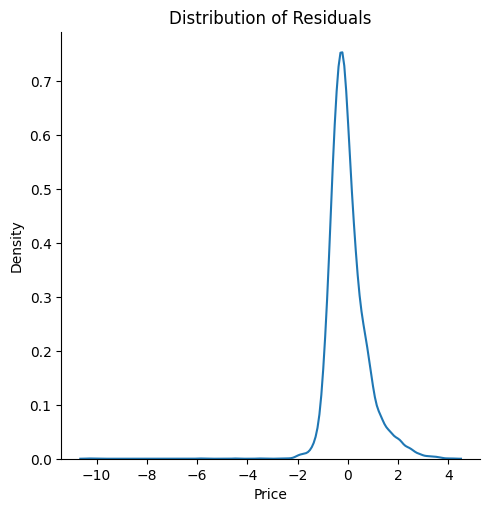

In [34]:
sns.displot(residuals, kind="kde")
plt.title("Distribution of Residuals")

### Residuals vs Predicted Values

This plot helps us check the homoscedasticity assumption.

If the residuals are randomly scattered around zero with no clear pattern, the assumption is satisfied.

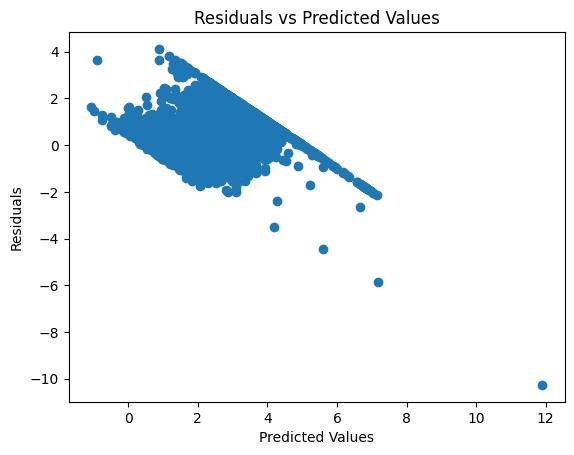

In [35]:
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

## Model Serialization using Pickle

After training the model, we can save it so that it can be reused later without retraining.

Pickle is a Python library used for saving machine learning models to a file.

In [36]:
import pickle

pickle.dump(regression, open('regressor.pkl', 'wb'))

### Load the Saved Model

In [37]:
model = pickle.load(open('regressor.pkl', 'rb'))

model.predict(X_test)

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012], shape=(6812,))